# Collect data over all EOM Voltage configurations

In [1]:
# The number of voltage steps per scan
N = 60

In [56]:
import nidaqmx
from nidaqmx.constants import Edge, CountDirection
import nidaqmx.system
import time
import numpy as np
import pandas as pd

# ==========================================
# EXPERIMENTAL SEQUENCE PARAMETERS
# ==========================================
v_sweep = np.linspace(-200, 200, N)
time_unit = 0.01 # seconds
timearray = np.ones(N*N) * time_unit

signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

device_name = "Dev1"
ao_channel_0 = f"{device_name}/ao0"
ao_channel_1 = f"{device_name}/ao1"       
pfi_pin_0 = f"/{device_name}/PFI1"
pfi_pin_1 = f"/{device_name}/PFI2"
HV_GAIN = 20.0

assert len(timearray) == len(signalarray0) == len(signalarray1), "Input arrays must be the same length."
total_sequence_time = sum(timearray)

recorded_data = []

# ==========================================
# DAQ EXECUTION (Synchronous / Headless)
# ==========================================
nidaqmx.system.Device(device_name).reset_device()
print(f"Hardware reset complete. Initializing DAQ tasks...")

try:
    with nidaqmx.Task() as ao_task, nidaqmx.Task() as ci_task0, nidaqmx.Task() as ci_task1:
        
        # Setup AO
        ao_task.ao_channels.add_ao_voltage_chan(ao_channel_0)
        ao_task.ao_channels.add_ao_voltage_chan(ao_channel_1)
        
        # Setup CI
        ci_chan0 = ci_task0.ci_channels.add_ci_count_edges_chan(
            f"{device_name}/ctr0", edge=Edge.RISING, initial_count=0, count_direction=CountDirection.COUNT_UP)
        ci_chan0.ci_count_edges_term = pfi_pin_0
        
        ci_chan1 = ci_task1.ci_channels.add_ci_count_edges_chan(
            f"{device_name}/ctr1", edge=Edge.RISING, initial_count=0, count_direction=CountDirection.COUNT_UP)
        ci_chan1.ci_count_edges_term = pfi_pin_1

        # Start Hardware
        ci_task0.start()
        ci_task1.start()
        ao_task.start()
        
        start_time = time.perf_counter()
        
        for step_idx in range(len(timearray)):
            step_dur = timearray[step_idx]
            target_v0 = signalarray0[step_idx]
            target_v1 = signalarray1[step_idx]
            
            # Peter Note 9/2/26: Inverting amplifier voltage
            daq_v0 = -max(-10.0, min(10.0, target_v0 / HV_GAIN))
            daq_v1 = -max(-10.0, min(10.0, target_v1 / HV_GAIN))
            
            # Apply voltages
            ao_task.write([daq_v0, daq_v1])

            # Grab initial counts
            c0_start = ci_task0.read()
            c1_start = ci_task1.read()
            step_start_time = time.perf_counter()
            
            # Wait interval
            while (time.perf_counter() - step_start_time) < step_dur:
                time.sleep(0.01) 
            
            # Grab final counts
            c0_end = ci_task0.read()
            c1_end = ci_task1.read()
            step_end_time = time.perf_counter()
            
            # Calculate rates
            dt = step_end_time - step_start_time
            hz0 = (c0_end - c0_start) / dt if dt > 0 else 0.0
            hz1 = (c1_end - c1_start) / dt if dt > 0 else 0.0
            
            elapsed = time.perf_counter() - start_time
            unix_timestamp = time.time()
            recorded_data.append((unix_timestamp, elapsed, target_v0, target_v1, c0_end, c1_end, hz0, hz1))
            
            # Print live update (carriage return overwrites the line)
            if step_idx % 5 == 0:
                print(f"Elapsed: {elapsed:.1f}s / {total_sequence_time:.1f}s | "
                      f"V0: {target_v0:.1f}V | V1: {target_v1:.1f}V | "
                      f"Rate0: {hz0:.1f}Hz | Rate1: {hz1:.1f}Hz", end='\r')
                
except KeyboardInterrupt:
    print("\n\nMeasurement interrupted by user in Jupyter Notebook.")
except Exception as e:
    print(f"\n\nDAQ Error: {e}")
finally:
    print("\nSequence complete. DAQ tasks closed.")

# ==========================================
# EXPORT DATA TO PANDAS DATAFRAME
# ==========================================
if recorded_data:
    df = pd.DataFrame(
        recorded_data, 
        columns=["Unix_Timestamp", "Elapsed_Time_s", "EOM0_Target_V", "EOM1_Target_V", "Raw_Count0", "Raw_Count1", "Rate0_Hz", "Rate1_Hz"]
    )
    print("Data loaded into DataFrame 'df'.")
else:
    df = pd.DataFrame()
    print("No data was recorded.")

Hardware reset complete. Initializing DAQ tasks...
Elapsed: 71.1s / 36.0s | V0: 172.9V | V1: 200.0V | Rate0: 629.0Hz | Rate1: 698.9Hzzzz
Sequence complete. DAQ tasks closed.
Data loaded into DataFrame 'df'.


# Fit theoretical curve to the data and extract EOM parameters

In [4]:
import pandas as pd

df = pd.read_csv("20260918_223941_Detector_Traces.csv")

Trace 0 Fit Parameters (A, k1, k2, phi, C): [ 5.54193321e+02  8.27883900e-03  1.80121980e-02 -8.77126034e-01
  1.17088494e+03]
Trace 0 R^2:  0.04170813793222805
Trace 1 Fit Parameters (A, k1, k2, phi, C): [ 1.73387703e+03  6.92633400e-03  7.14659300e-03 -8.25171293e-01
  2.64089182e+02]
Trace 1 R^2:  0.7839746891904458


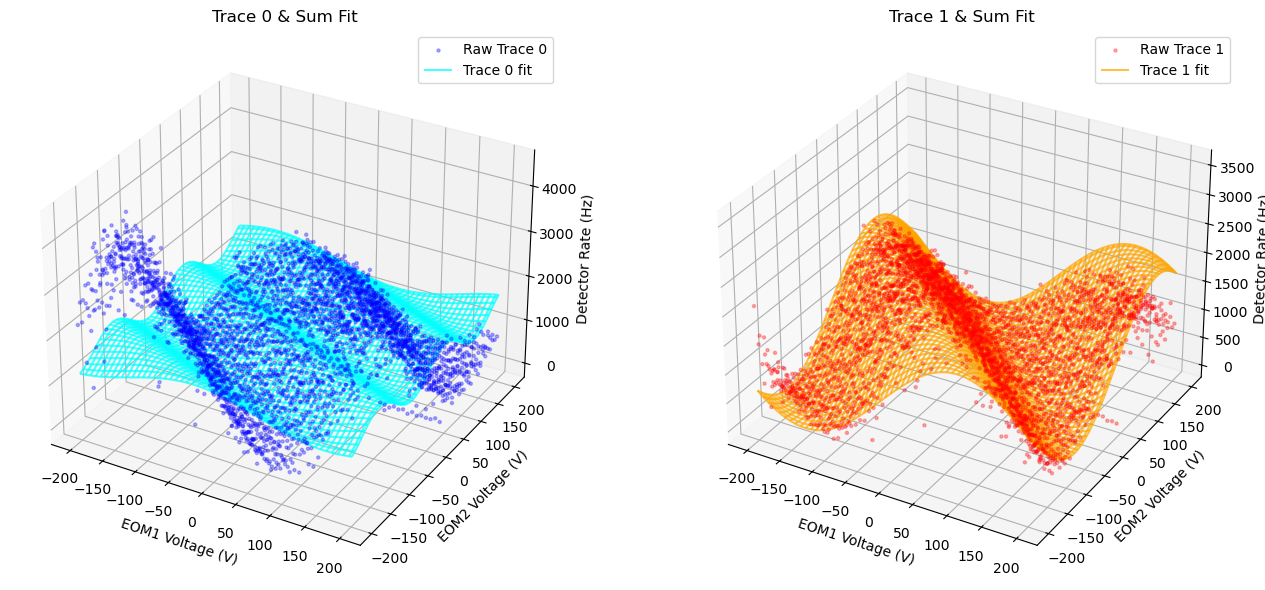

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, N)
signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

# 2. Load the detector trace data
# df comes from reading above
# df = pd.read_csv("20260916_220636_Detector_Traces.csv")
z0 = df['Rate0_Hz'].values
z1 = df['Rate1_Hz'].values

# 3. Define the updated 2D interference fitting function
def new_eom_model(xy, A, k1, k2, phi, C):
    x, y = xy
    return A * (np.sin(k1 * x + k2 * y + phi)**2) + C

# 4. Execute the curve fitting for both traces
# Initial parameter guesses: [Amplitude, k1, k2, phi, Offset]
p0_guess0 = [np.max(z0) - np.min(z0), 0.01, 0.01, 0, np.min(z0)]
try:
    popt0, pcov0 = curve_fit(new_eom_model, (signalarray0, signalarray1), z0, p0=p0_guess0)
except RuntimeError:
    # Fallback guess if optimization fails to converge
    print("Fitting to Trace 0 failed to converge")

p0_guess1 = [np.max(z1) - np.min(z1), 0.01, 0.01, 0, np.min(z1)]
try:
    popt1, pcov1 = curve_fit(new_eom_model, (signalarray0, signalarray1), z1, p0=p0_guess1)
except RuntimeError:
    # Fallback guess if optimization fails to converge
    print("Fitting to Trace 1 failed to converge")

# CALCULATING R^2 VALUES

# Calculate the predicted Z values using the optimized parameters
z0_fit = new_eom_model((signalarray0, signalarray1), *popt0)
# Calculate the Residual Sum of Squares (SS_res)
ss_res0 = np.sum((z0 - z0_fit)**2)
# Calculate the Total Sum of Squares (SS_tot)
ss_tot0 = np.sum((z0 - np.mean(z0))**2)
# Compute R^2
r_squared0 = 1 - (ss_res0 / ss_tot0)

# Calculate the predicted Z values using the optimized parameters
z1_fit = new_eom_model((signalarray0, signalarray1), *popt1)
# Calculate the Residual Sum of Squares (SS_res)
ss_res1 = np.sum((z1 - z1_fit)**2)
# Calculate the Total Sum of Squares (SS_tot)
ss_tot1 = np.sum((z1 - np.mean(z0))**2)
# Compute R^2
r_squared1 = 1 - (ss_res1 / ss_tot1)


print(f"Trace 0 Fit Parameters (A, k1, k2, phi, C): {np.round(popt0, 9)}")
print(f"Trace 0 R^2: ", r_squared0)
print(f"Trace 1 Fit Parameters (A, k1, k2, phi, C): {np.round(popt1, 9)}")
print(f"Trace 1 R^2: ", r_squared1)

# 5. Generate a high-resolution meshgrid for smooth surface plotting
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))
Z0_fit = new_eom_model((X, Y), *popt0)
Z1_fit = new_eom_model((X, Y), *popt1)

# 6. Initialize the 3D plot with two subplots
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Trace 0
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(signalarray0, signalarray1, z0, c='blue', s=5, alpha=0.3, label='Raw Trace 0')
ax1.plot_wireframe(X, Y, Z0_fit, color='cyan', alpha=0.7, label='Trace 0 fit')
ax1.set_xlabel('EOM1 Voltage (V)')
ax1.set_ylabel('EOM2 Voltage (V)')
ax1.set_zlabel('Detector Rate (Hz)')
ax1.set_title('Trace 0 & Sum Fit')
ax1.legend()

# Subplot 2: Trace 1
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(signalarray0, signalarray1, z1, c='red', s=5, alpha=0.3, label='Raw Trace 1')
ax2.plot_wireframe(X, Y, Z1_fit, color='orange', alpha=0.7, label='Trace 1 fit')
ax2.set_xlabel('EOM1 Voltage (V)')
ax2.set_ylabel('EOM2 Voltage (V)')
ax2.set_zlabel('Detector Rate (Hz)')
ax2.set_title('Trace 1 & Sum Fit')
ax2.legend()

plt.tight_layout()
plt.show()

# Decide EOM voltages for BB84 photon manipulation

EOM0_VPI 233.01155822499584
EOM1_VPI 189.4742191461296
EOM0Voltages =  [np.float64(-115.18934627685923), np.float64(1.3164328356386932), np.float64(117.82221194813661), np.float64(234.32799106063453)]
EOM1Voltages =  [0, np.float64(94.7371095730648)]


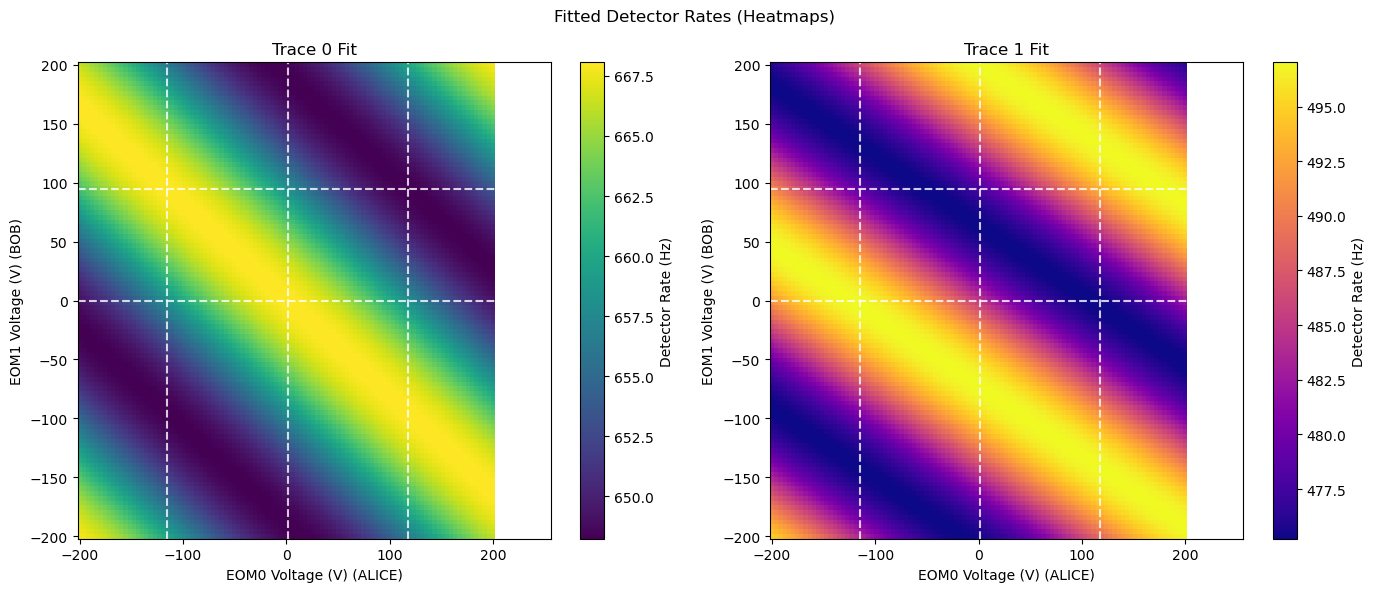

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the fitted interference model
def new_eom_model(x, y, A, k1, k2, phi, C):
    return A * (np.sin(k1 * x + k2 * y + phi)**2) + C

# 2. Input the provided optimal fit parameters
params0 = popt0
params1 = popt1

# 3. Generate a meshgrid
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))

# 4. Calculate the corresponding Z (Rate) values
Z0_fit = new_eom_model(X, Y, *params0)
Z1_fit = new_eom_model(X, Y, *params1)

# 5. Initialize the 2D subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 6. Plot using pcolormesh for the heatmaps
c1 = ax1.pcolormesh(X, Y, Z0_fit, cmap='viridis', shading='auto')
c2 = ax2.pcolormesh(X, Y, Z1_fit, cmap='plasma', shading='auto')
fig.colorbar(c1, ax=ax1, label='Detector Rate (Hz)')
fig.colorbar(c2, ax=ax2, label='Detector Rate (Hz)')

# 7. Set voltages for all states based on EOM parameters, and plot
# vertical/horizontal lines for each voltage for visual verification
EOM0_VPI = np.pi/params0[1]/2
EOM1_VPI = np.pi/params0[2]/2

print('EOM0_VPI', EOM0_VPI)
print('EOM1_VPI', EOM1_VPI)

# Initial base voltage calculation
V_EOM0_set_0 = -params0[3]/params0[1] - EOM0_VPI/2

# --- Wrapping Logic ---
# The span of Alice's 4 voltages is 1.5 * EOM0_VPI. 
# We find the midpoint of this span to center it around 0V.
period = 2 * EOM0_VPI
midpoint = V_EOM0_set_0 + (1.5 * EOM0_VPI) / 2

# Calculate how many 2*Vpi periods we need to shift to get the midpoint near 0
shifts = np.round(midpoint / period)

# Shift the base voltage
V_EOM0_set_0 -= shifts * period
# ----------------------

# --- Add vertical and horizontal lines ---
V_EOM0_set_1 = V_EOM0_set_0  # Set your desired X-coordinate
V_EOM0_set_2 = V_EOM0_set_0 + EOM0_VPI/2 
V_EOM0_set_3 = V_EOM0_set_0 + 2*EOM0_VPI/2 
V_EOM0_set_4 = V_EOM0_set_0 + 3*EOM0_VPI/2 

EOM0Voltages = [V_EOM0_set_1, V_EOM0_set_2, V_EOM0_set_3, V_EOM0_set_4]

ax1.axvline(x=V_EOM0_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=V_EOM0_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=V_EOM0_set_3, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_3, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=V_EOM0_set_4, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_4, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

V_EOM1_set_1 = 0  # Set your desired Y-coordinate
V_EOM1_set_2 = 0 + EOM1_VPI/2

EOM1Voltages = [V_EOM1_set_1, V_EOM1_set_2]

ax1.axhline(y=V_EOM1_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axhline(y=V_EOM1_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axhline(y=V_EOM1_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axhline(y=V_EOM1_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

print('EOM0Voltages = ', EOM0Voltages)
print('EOM1Voltages = ', EOM1Voltages)

# 8. Format the axes and titles
ax1.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax1.set_ylabel('EOM1 Voltage (V) (BOB)')
ax1.set_title('Trace 0 Fit')

ax2.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax2.set_ylabel('EOM1 Voltage (V) (BOB)')
ax2.set_title('Trace 1 Fit')

fig.suptitle('Fitted Detector Rates (Heatmaps)')

# 9. Display the plot
plt.tight_layout()
plt.show()

# Plot four by four BB84 protocol logic matrix

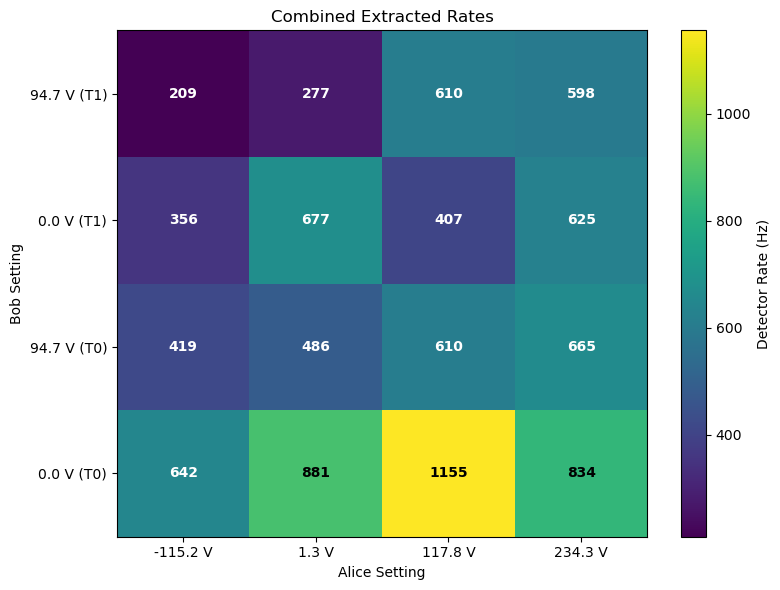

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, N)
signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

# 3. Extract the 8 closest points into 2x4 matrices
rate0_grid = np.zeros((2, 4))
rate1_grid = np.zeros((2, 4))

for i, v1_ideal in enumerate(EOM1Voltages):
    for j, v0_ideal in enumerate(EOM0Voltages):
        distances = (signalarray0 - v0_ideal)**2 + (signalarray1 - v1_ideal)**2
        idx = np.argmin(distances)
        
        rate0_grid[i, j] = z0[idx]
        rate1_grid[i, j] = z1[idx]

# 4. Combine the grids into a single 4x4 matrix
# np.vstack puts rate0_grid at indices 0,1 and rate1_grid at 2,3.
# With origin='lower', indices 2,3 (Trace 1) appear above indices 0,1 (Trace 0).
combined_grid = np.vstack((rate0_grid, rate1_grid))

# Combine Y-axis labels to distinguish the traces
combined_y_labels = [f"{v:.1f} V (T0)" for v in EOM1Voltages] + [f"{v:.1f} V (T1)" for v in EOM1Voltages]

# 5. Plot the 4x4 heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(combined_grid, origin='lower', cmap='viridis', aspect='auto')

# 6. Add colorbar shared for both traces
fig.colorbar(im, ax=ax, label='Detector Rate (Hz)')

# 7. Format axes and annotate values
ax.set_xticks(np.arange(len(EOM0Voltages)))
ax.set_yticks(np.arange(len(combined_y_labels)))

x_labels = [f"{v:.1f} V" for v in EOM0Voltages]

# Label ticks with rounded voltage values and trace identifiers
ax.set_xticklabels(x_labels)
ax.set_yticklabels(combined_y_labels)

ax.set_xlabel('Alice Setting')
ax.set_ylabel('Bob Setting')
ax.set_title('Combined Extracted Rates')

# Annotate each cell with the exact count rate
threshold = np.max(combined_grid) * 0.6  # Threshold for text color contrast
for i in range(combined_grid.shape[0]):
    for j in range(combined_grid.shape[1]):
        val = combined_grid[i, j]
        text_color = "white" if val < threshold else "black"
        ax.text(j, i, f"{int(val)}", ha="center", va="center", color=text_color, fontweight='bold')

# 8. Display the plot
plt.tight_layout()
plt.show()




C:\Users\nanometa\AppData\Local\Temp\ipykernel_56436\538136047.py:93: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


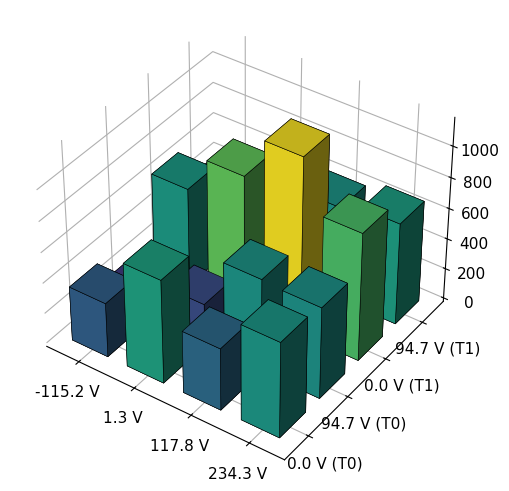

In [60]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, N)
signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

# 3. Extract the closest points into 2x4 matrices
rate0_grid = np.zeros((2, 4))
rate1_grid = np.zeros((2, 4))

for i, v1_ideal in enumerate(EOM1Voltages):
    for j, v0_ideal in enumerate(EOM0Voltages):
        distances = (signalarray0 - v0_ideal) ** 2 + (signalarray1 - v1_ideal) ** 2
        idx = np.argmin(distances)

        rate0_grid[i, j] = z0[idx]
        rate1_grid[i, j] = z1[idx]

# 4. Combine grids into a single 4x4 matrix
combined_grid = np.vstack((rate0_grid, rate1_grid))

# Swapping to get into literature form; adjust as needed here
combined_grid[[0,2]] = combined_grid[[2,0]]
combined_grid[[1,3]] = combined_grid[[3,1]]

# 5. Build the 3D pillar (bar3d) plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

num_y, num_x = combined_grid.shape
x_pos, y_pos = np.meshgrid(np.arange(num_x), np.arange(num_y))

x_pos = x_pos.ravel()
y_pos = y_pos.ravel()
z_pos = np.zeros_like(x_pos)

# Pillar dimensions
dx = 0.65
dy = 0.65
dz = combined_grid.ravel()

# Center pillars on tick positions
x_pos = x_pos - dx / 2
y_pos = y_pos - dy / 2

# Map colormap to bar heights (viridis matching reference)
norm = mcolors.Normalize(vmin=0, vmax=np.max(dz) if np.max(dz) > 0 else 1)
cmap = cm.viridis
facecolors = cmap(norm(dz))

# Render 3D pillars
ax.bar3d(
    x_pos,
    y_pos,
    z_pos,
    dx,
    dy,
    dz,
    color=facecolors,
    edgecolor="black",
    linewidth=0.4,
    shade=True,
)

# 6. Styling to match the reference format
ax.view_init(elev=38, azim=-55)
ax.set_box_aspect((1, 1, 0.8))

# Tick placements & labels
ax.set_xticks(np.arange(num_x))
ax.set_yticks(np.arange(num_y))

x_labels = [f"{v:.1f} V" for v in EOM0Voltages]
combined_y_labels = [f"{v:.1f} V (T0)" for v in EOM1Voltages] + [
    f"{v:.1f} V (T1)" for v in EOM1Voltages
]

ax.set_xticklabels(x_labels, fontsize=11)
ax.set_yticklabels(combined_y_labels, fontsize=11)
ax.tick_params(axis="z", labelsize=11)

# Clean white background with subtle gridlines
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.grid(True, linestyle="-", color="lightgray", alpha=0.7)

plt.tight_layout()
plt.show()